# UHPC Compressive Strength — Exploratory Data Analysis

**Author:** K Flowers  
**Date:** January 2026

[2-3 sentence description of notebook purpose + brief problem statement]

**Pipeline Position:** Notebook 1 of 2 — Exploratory Analysis
- 01_exploratory_analysis.ipynb ← this notebook
- 02_model_development.ipynb

**Objective:** [One sentence goal]

**Technical Approach:**
- Validate data quality (missing values, duplicates, invalid ranges)
- Analyze target and feature distributions
- Examine feature-target relationships and statistical significance
- Assess multicollinearity for model selection

**Inputs:**
- `data/uhpc_dataset.csv` — 810 UHPC mix designs with 13 features

**Outputs:**
- Key insights for model development
- Saved visualizations to `images/` folder

**Runtime:** ~5 minutes

---
## 1. Configure Environment

### 1.1 Import Libraries

In [41]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Libraries imported successfully")


Libraries imported successfully


In [35]:
import buckaroo

Buckaroo has been enabled as the default DataFrame viewer.  To return to default dataframe visualization use `from buckaroo import disable; disable()`


### 1.2 Set Display and Plot Options

In [42]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [44]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input/output files
INPUT_FILE = DATA_DIR / "uhpc_dataset.csv"

# Constants
RANDOM_STATE = 42

print("Paths and constants set")

Paths and constants set


### 1.4 Define Helper Functions

In [ ]:
# No helper functions needed - using pd.cut() and np.where() for classifications
print("Helper functions: None required")

---
## 2. Load Data

TODO **Methodology:** Explain variable selection rationale based on UHPC literature.

In [46]:
#Load the UHPC dataset from CSV file
df = pd.read_csv(INPUT_FILE)

print(f"Dataset loaded: {INPUT_FILE.name}")
print(f"  Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded: uhpc_dataset.csv
  Shape: 810 rows, 14 columns


In [47]:
# Rename columns from abbreviations to descriptive names
column_mapping = {
    'C': 'cement',
    'W': 'water',
    'FA': 'fly_ash',
    'SF': 'silica_fume',
    'NS': 'nano_silica',
    'QP': 'quartz_powder',
    'LP': 'limestone_powder',
    'A': 'aggregate',
    'S': 'slag',
    'SP': 'superplasticizer',
    'Fi': 'fiber',
    'T': 'temperature',
    'Age': 'age',
    'CS': 'compressive_strength'
}

df = df.rename(columns=column_mapping)

print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder', 'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber', 'superplasticizer', 'temperature', 'age', 'compressive_strength']


In [48]:
# WHAT: Define target variable and analysis constants
# WHY: Centralizes variable definitions for easy modification and consistency
TARGET = 'compressive_strength'
HURRICANE_THRESHOLD = 150  # MPa threshold for hurricane-resistant concrete

print(f"Target variable: {TARGET}")
print(f"Hurricane threshold: {HURRICANE_THRESHOLD} MPa")

Target variable: compressive_strength
Hurricane threshold: 150 MPa


### Variable Units

**Mix components** (kg/m³):
- cement, slag, silica_fume, limestone_powder, quartz_powder, fly_ash, nano_silica, aggregate, water, fiber, superplasticizer

**Curing conditions:**
- temperature (°C)
- age (days)

**Target:**
- compressive_strength (MPa)

See Appendix A for detailed validation ranges and literature sources.

In [49]:
# Display dataset shape, data types, and first rows
print("Data Types:")
print(df.dtypes)
df.head()

Data Types:
cement                  float64
slag                    float64
silica_fume             float64
limestone_powder        float64
quartz_powder           float64
fly_ash                 float64
nano_silica             float64
aggregate               float64
water                   float64
fiber                   float64
superplasticizer        float64
temperature               int64
age                       int64
compressive_strength    float64
dtype: object


,cement,slag,silica_fume,limestone_powder,quartz_powder,fly_ash,nano_silica,aggregate,water,fiber,superplasticizer,temperature,age,compressive_strength
0,450.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.0000,1992.0000,90.0000,0.0000,18.0000,20,28,131.0000
1,630.0000,0.0000,70.0000,0.0000,0.0000,0.0000,0.0000,1788.0000,126.0000,0.0000,18.0000,20,28,135.0000
2,810.0000,0.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,162.0000,0.0000,18.0000,20,28,137.0000
3,810.0000,0.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,162.0000,0.0000,18.0000,20,28,137.0000
4,630.0000,180.0000,90.0000,0.0000,0.0000,0.0000,0.0000,1539.0000,126.0000,0.0000,18.0000,20,28,150.0000


---
## 3. Validate Data Quality

**Methodology:** Reference valid ranges from materials science literature (e.g., cement content, w/c ratios).

### 3.1 Check Missing Values

In [50]:
# Check for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
cement                  0
slag                    0
silica_fume             0
limestone_powder        0
quartz_powder           0
fly_ash                 0
nano_silica             0
aggregate               0
water                   0
fiber                   0
superplasticizer        0
temperature             0
age                     0
compressive_strength    0
dtype: int64


### 3.2 Check Invalid Values

Flag rows with negative values or values outside expected ranges (see Appendix A).

In [58]:
# Check for negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Flag rows with any negative values
df['has_negatives'] = (df[numeric_cols] < 0).any(axis=1)

total_rows = len(df)
rows_with_negatives = df['has_negatives'].sum()
rows_without_negatives = total_rows - rows_with_negatives

print("Negative Value Check:")
print(f"  Total rows:                      {total_rows}")
print(f"  Rows with negatives (flagged):   {rows_with_negatives}")
print(f"  Rows without negatives:          {rows_without_negatives}")


Negative Value Check:
  Total rows:                      810
  Rows with negatives (flagged):   0
  Rows without negatives:          810


In [55]:
# Define validation ranges for each variable as min, max tuples
VALIDATION_RANGES = {
    'cement':              (200, 1500),
    'slag':                (0, 600),
    'silica_fume':         (0, 500),
    'limestone_powder':    (0, 1200),
    'quartz_powder':       (0, 500),
    'fly_ash':             (0, 400),
    'nano_silica':         (0, 100),
    'aggregate':           (0, 2500),
    'water':               (50, 350),
    'fiber':               (0, 300),
    'superplasticizer':    (0, 100),
    'temperature':         (0, 250),
    'age':                 (1, 1000),
    'compressive_strength': (0, 350)
}

print("Validation Ranges:")
print(f"  {len(VALIDATION_RANGES)} thresholds defined")

Validation Ranges:
  14 thresholds defined


In [60]:
# Validate values against thresholds using vectorized operations
out_of_range_mask = pd.Series(False, index=df.index)
for col, (min_val, max_val) in VALIDATION_RANGES.items():
    if col in df.columns:
        out_of_range_mask |= (df[col] < min_val) | (df[col] > max_val)

df['has_out_of_range'] = out_of_range_mask

total_rows = len(df)
rows_out_of_range = df['has_out_of_range'].sum()
rows_in_range = total_rows - rows_out_of_range

print("Range Validation Check:")
print(f"  Total rows:                     {total_rows}")
print(f"  Rows out of range (flagged):    {rows_out_of_range}")
print(f"  Rows within valid range:        {rows_in_range}")

Range Validation Check:
  Total rows:                     810
  Rows out of range (flagged):    0
  Rows within valid range:        810


### 3.3 Check Duplicates

Note: Duplicates may be valid repeated experiments or data entry errors - requires review.

In [ ]:
# Check for duplicate rows and flag 
original_cols = [col for col in df.columns if col not in ['has_negatives', 'has_out_of_range', 'has_duplicate']]
df['has_duplicate'] = df.duplicated(subset=original_cols, keep='first')
duplicate_count = df['has_duplicate'].sum()

print("Duplicate Row Check:")
print(f"  Duplicate rows (flagged): {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

Duplicate Row Check:
  Duplicate rows: 18 (2.22%)


### 3.4 Summary Statistics

In [62]:
# Display summary statistics for all numeric columns including non-zero counts
print("Summary Statistics:")

# Get standard describe statistics
stats_df = df.describe().T

# Add non-zero count column
stats_df['non_zero_records'] = (df > 0).sum()

# Rename count to total_records for clarity
stats_df = stats_df.rename(columns={'count': 'total_records'})

# Reorder columns to put non_zero_records after total_records
cols = ['total_records', 'non_zero_records', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
stats_df = stats_df[cols]

stats_df

Summary Statistics:


,total_records,non_zero_records,mean,std,min,25%,50%,75%,max
cement,810.0000,810,737.9146,173.4572,270.0000,620.2000,770.5000,850.0000,1251.2000
slag,810.0000,98,25.1946,74.3655,0.0000,0.0000,0.0000,0.0000,375.0000
silica_fume,810.0000,639,136.9872,104.1446,0.0000,43.7000,144.0000,219.0000,433.7000
limestone_powder,810.0000,114,41.9295,133.1315,0.0000,0.0000,0.0000,0.0000,1058.2000
quartz_powder,810.0000,132,33.2710,79.6739,0.0000,0.0000,0.0000,0.0000,397.0000
fly_ash,810.0000,117,26.2649,67.4617,0.0000,0.0000,0.0000,0.0000,356.0000
nano_silica,810.0000,211,3.6386,7.7760,0.0000,0.0000,0.0000,4.0000,47.5000
aggregate,810.0000,810,1150.1100,312.1520,407.8000,873.0000,1116.0000,1301.4000,1992.0000
water,810.0000,810,179.8911,25.5682,90.0000,163.0000,177.0000,192.5000,272.6000
fiber,810.0000,329,56.0444,75.2306,0.0000,0.0000,0.0000,156.0000,234.0000


### 3.5 Filter Invalid Rows

Remove rows with data quality issues before proceeding with analysis.

In [63]:
# Filter out rows with neg, out-of-range, or duplicate data 
rows_before = len(df)

# Remove rows with negatives, out-of-range values, or duplicates
df = df[~(df['has_negatives'] | df['has_out_of_range'] | df['has_duplicate'])].copy()

# Drop helper columns
df = df.drop(columns=['has_negatives', 'has_out_of_range', 'has_duplicate'])

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Data Filtering Summary:")
print(f"  Rows before: {rows_before}")
print(f"  Rows removed: {rows_removed}")
print(f"  Rows after: {rows_after}")
print(f"  Retention rate: {rows_after/rows_before*100:.1f}%")

Data Filtering Summary:
  Rows before: 810
  Rows removed: 18
  Rows after: 792
  Retention rate: 97.8%


---
## 4. Analyze Target Variable (Compressive Strength)

**Methodology:** "Understanding the target distribution is essential for regression model selection. Non-normal targets may benefit from tree-based methods or require transformation for linear models (James et al., 2021)."

### 4.1 Distribution (Histogram + KDE)

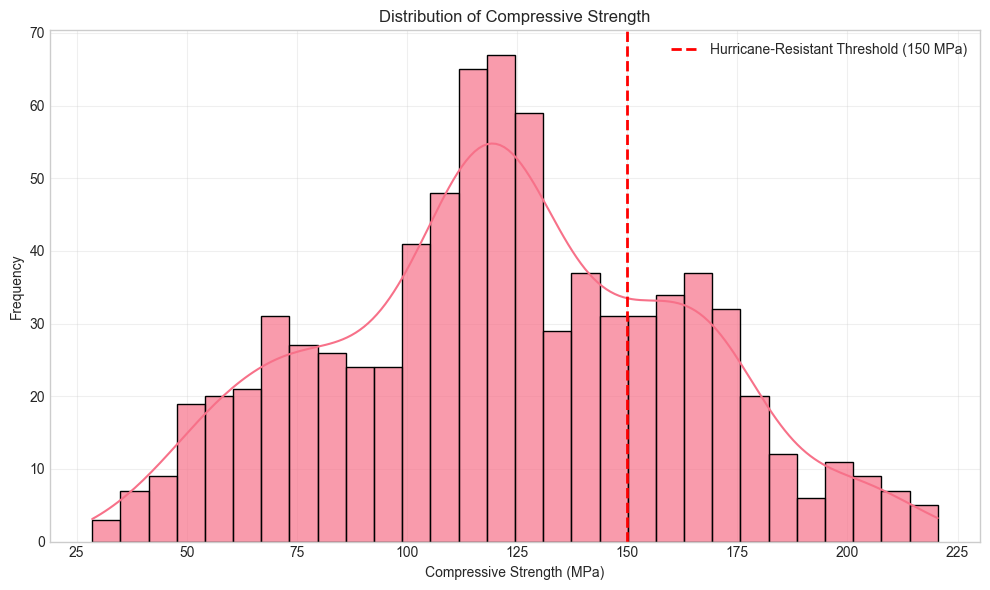

Figure saved: target_distribution.png


In [64]:
# WHAT: Plot histogram with kernel density estimate for target variable
# WHY: Visualizing distribution shape informs model selection and transformation needs
plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET], kde=True, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=HURRICANE_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'Hurricane-Resistant Threshold ({HURRICANE_THRESHOLD} MPa)')
plt.title(f'Distribution of Compressive Strength', fontsize=12)
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: target_distribution.png")

In [24]:
# WHAT: Display descriptive statistics for target variable using describe()
# WHY: Concise summary of central tendency and spread for reporting
print(f"Target Variable: {TARGET}\n")
print(df[TARGET].describe().round(2))
print(f"\nIQR: {df[TARGET].quantile(0.75) - df[TARGET].quantile(0.25):.2f} MPa")

Target Variable: compressive_strength

count   792.0000
mean    122.0900
std      40.0100
min      28.5100
25%      94.6000
50%     120.9000
75%     151.0000
max     220.5000
Name: compressive_strength, dtype: float64

IQR: 56.40 MPa


### 4.3 Normality Testing

- Shapiro-Wilk test (H₀: data is normally distributed)
- Q-Q plot for visual assessment
- Skewness and kurtosis with interpretation thresholds

Shapiro-Wilk Test:
  Statistic: 0.9910
  p-value:   0.0001


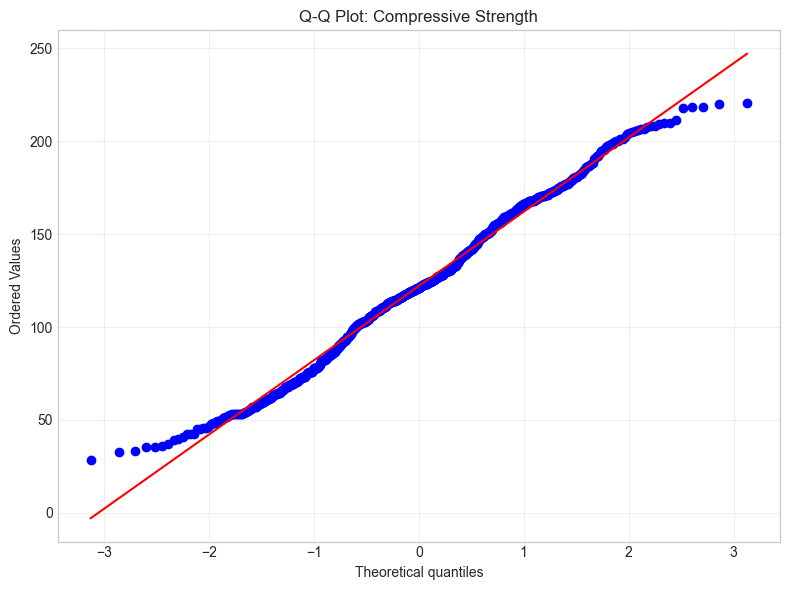


Figure saved: qq_plot_target.png


In [25]:
# WHAT: Create sample and perform normality tests with Q-Q plot
# WHY: Normality assessment informs model selection and transformation decisions
target_sample = df[TARGET].sample(5000, random_state=RANDOM_STATE) if len(df) > 5000 else df[TARGET]

# Shapiro-Wilk test
stat, p_value = stats.shapiro(target_sample)
print("Shapiro-Wilk Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {p_value:.4f}")

# Q-Q Plot
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(target_sample, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Compressive Strength')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'qq_plot_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: qq_plot_target.png")

**Interpretation:** The Shapiro-Wilk test rejects normality (p < 0.05), but with n=792, even minor deviations become significant. The histogram and skewness suggest the data is approximately normal for practical purposes. No transformation needed.

**Note:** We test target normality to inform model selection and transformation decisions. Residual normality will be assessed during model validation in Notebook 02.

In [26]:
# Calculate skewness and kurtosis for target variable
skewness = df[TARGET].skew()
kurtosis = df[TARGET].kurtosis()

# Evaluate skewness > 1 suggests transformation may improve linear model performance
print("Shape Statistics:")
print(f"  Skewness: {skewness:.3f}")
if abs(skewness) < 0.5:
    print("    Interpretation: Approximately symmetric")
elif abs(skewness) < 1:
    print("    Interpretation: Moderately skewed")
else:
    print("    Interpretation: Highly skewed - consider transformation")

# Evaluate kurtosis - |k| > 1 indicates non-normal tails
print(f"  Kurtosis: {kurtosis:.3f}")
if abs(kurtosis) < 1:
    print("    Interpretation: Near normal tails (mesokurtic)")
elif kurtosis > 1:
    print("    Interpretation: Heavy tails (leptokurtic) - more outliers than normal")
else:
    print("    Interpretation: Light tails (platykurtic) - fewer outliers than normal")

Shape Statistics:
  Skewness: 0.034
    Interpretation: Approximately symmetric
  Kurtosis: -0.506
    Interpretation: Near normal tails (mesokurtic)


### 4.4 Hurricane-Resistant Threshold Analysis

Analyze samples meeting hurricane-resistant threshold (≥ 150 MPa).
- Percentage of samples meeting threshold
- Practical significance for infrastructure applications

In [65]:
# Calculate percentage of samples meeting hurricane-resistant threshold
above_threshold = (df[TARGET] >= HURRICANE_THRESHOLD).sum()
below_threshold = len(df) - above_threshold

print(f"Hurricane-Resistant Threshold Analysis ({HURRICANE_THRESHOLD} MPa):")
print(f"  Samples >= {HURRICANE_THRESHOLD} MPa: {above_threshold} ({above_threshold/len(df)*100:.1f}%)")
print(f"  Samples <  {HURRICANE_THRESHOLD} MPa: {below_threshold} ({below_threshold/len(df)*100:.1f}%)")
print(f"\n  Mean strength above threshold: {df[df[TARGET] >= HURRICANE_THRESHOLD][TARGET].mean():.2f} MPa")
print(f"  Mean strength below threshold: {df[df[TARGET] < HURRICANE_THRESHOLD][TARGET].mean():.2f} MPa")

Hurricane-Resistant Threshold Analysis (150 MPa):
  Samples >= 150 MPa: 210 (26.5%)
  Samples <  150 MPa: 582 (73.5%)

  Mean strength above threshold: 172.83 MPa
  Mean strength below threshold: 103.78 MPa


**Note:** This threshold analysis provides domain context for infrastructure applications. For regression modeling, the imbalance does not require resampling (unlike classification). However, we may use threshold-stratified train/test splits to ensure representative evaluation.

---
## 5. Analyze Features

**Methodology:** "Univariate analysis identifies features requiring transformation and potential outliers. For regression, features with high skewness (|skew| > 1) may benefit from log or Box-Cox transformation (Osborne, 2010). Pearson correlation measures linear association strength, with effect sizes following Cohen's conventions: |r| < 0.3 weak, 0.3-0.5 moderate, > 0.5 strong (Cohen, 1988)."

### 5.1 Feature Distributions (Histograms + KDE)

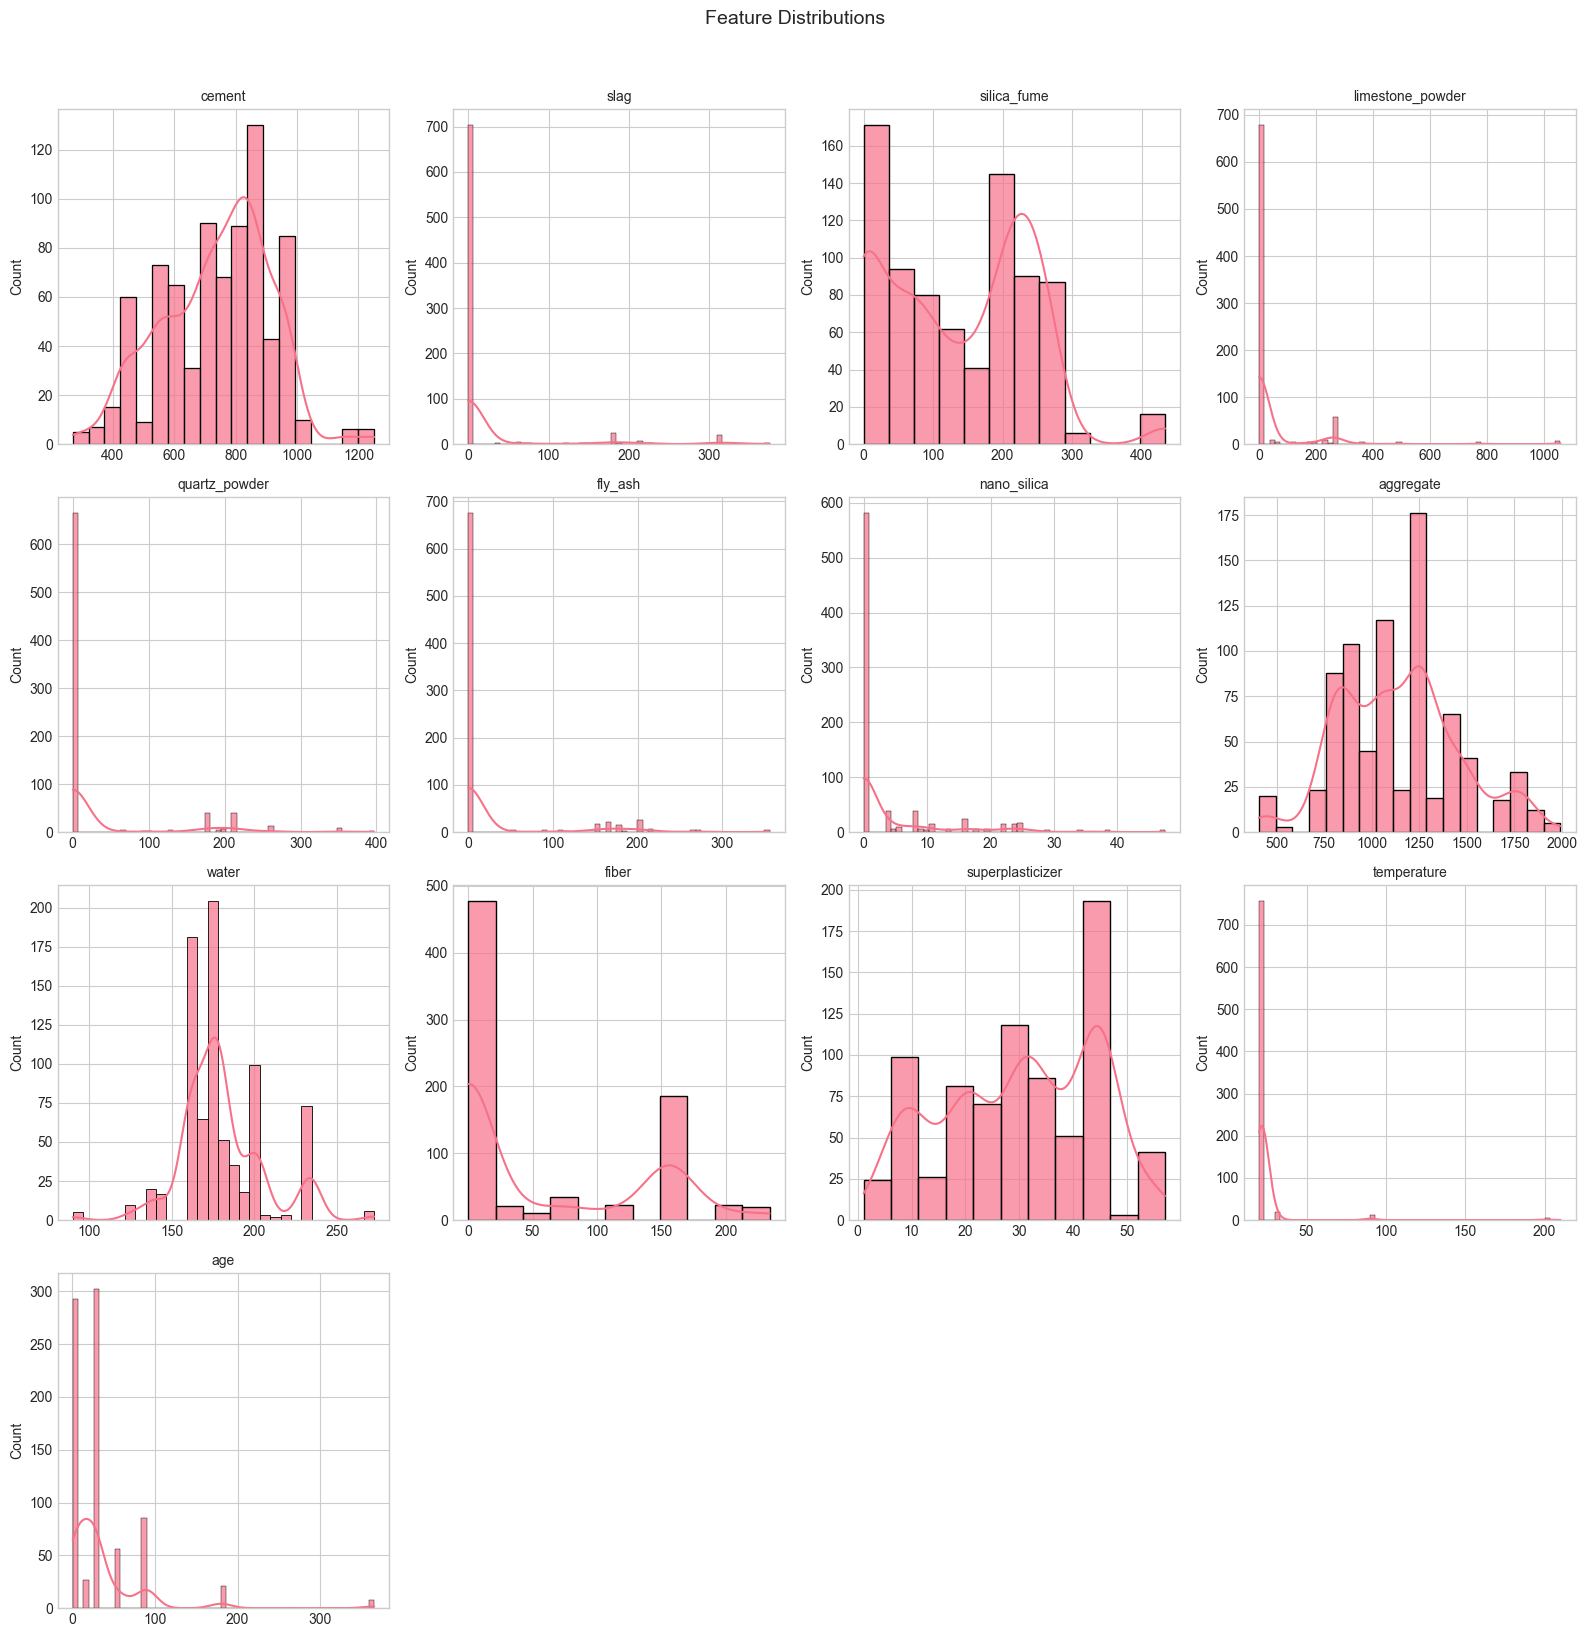

Figure saved: feature_distributions.png


In [66]:
# WHAT: Create histogram grid showing distribution of all features
# WHY: Univariate distributions reveal skewness, modality, and transformation needs
FEATURES = [col for col in df.columns if col != TARGET]
n_features = len(FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: feature_distributions.png")

### 5.2 Outlier Detection (Boxplots)

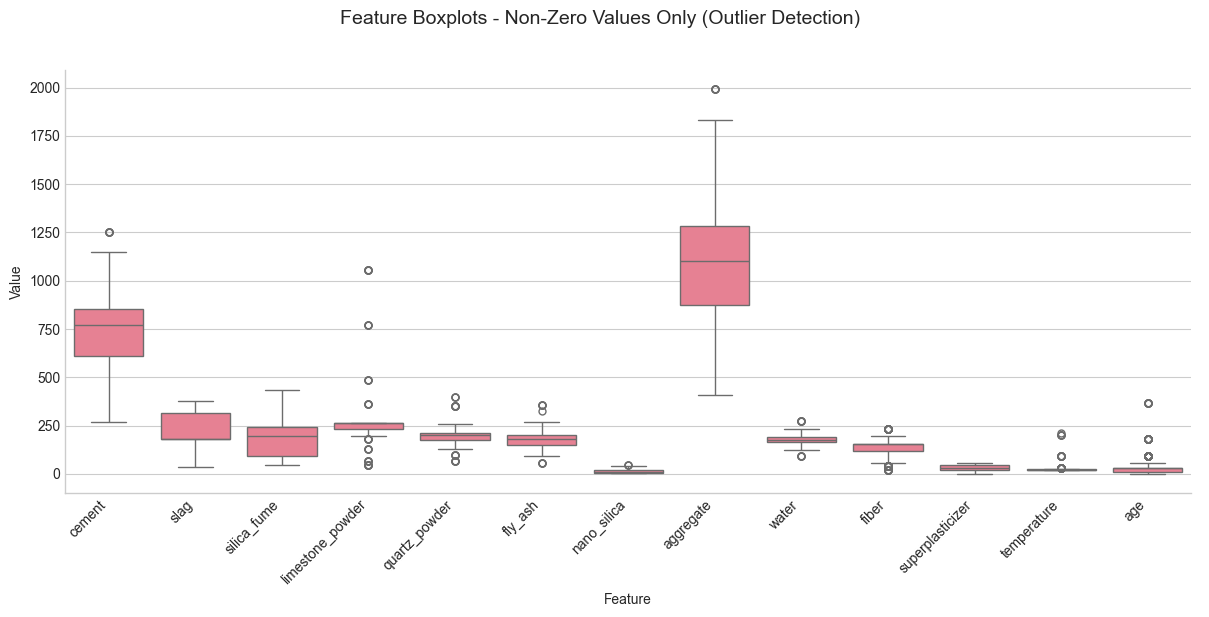


Figure saved: feature_boxplots.png


In [73]:
# Create boxplots for non-zero values using melt + seaborn
# Filter to features with >10 non-zero records
features_with_data = [col for col in FEATURES if (df[col] > 0).sum() > 10]

# Melt dataframe and filter to non-zero values
df_melted = df[features_with_data].melt(var_name='feature', value_name='value')
df_melted = df_melted[df_melted['value'] > 0]

# Create faceted boxplots (vertical orientation)
g = sns.catplot(
    data=df_melted, 
    x='feature', 
    y='value',
    kind='box',
    height=6,
    aspect=2
)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('Feature', 'Value')
g.fig.suptitle('Feature Boxplots - Non-Zero Values Only (Outlier Detection)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: feature_boxplots.png")

### 5.3 Skewness and Kurtosis Assessment

- Flag features with |skew| > 1
- Discuss transformation candidates

In [69]:
# WHAT: Calculate skewness and kurtosis for all features
# WHY: Features with |skew| > 1 are candidates for log or Box-Cox transformation
shape_stats = pd.DataFrame({
    'Skewness': df[FEATURES].skew(),
    'Kurtosis': df[FEATURES].kurtosis()
})
shape_stats['Abs_Skew'] = shape_stats['Skewness'].abs()
shape_stats['Transform_Candidate'] = shape_stats['Abs_Skew'] > 1
shape_stats = shape_stats.sort_values('Abs_Skew', ascending=False)

print("Skewness and Kurtosis Assessment:")
print(shape_stats.round(3))

print(f"\nTransformation candidates (|skew| > 1): {shape_stats['Transform_Candidate'].sum()}")

Skewness and Kurtosis Assessment:
                  Skewness  Kurtosis  Abs_Skew  Transform_Candidate
temperature         9.0430   89.6480    9.0430                 True
limestone_powder    4.7000   27.6480    4.7000                 True
age                 3.8900   20.5380    3.8900                 True
slag                3.1750    9.1880    3.1750                 True
nano_silica         2.4940    6.4810    2.4940                 True
fly_ash             2.4520    5.1220    2.4520                 True
quartz_powder       2.3110    4.4030    2.3110                 True
fiber               0.8070   -0.9940    0.8070                False
water               0.6020    1.7100    0.6020                False
aggregate           0.2750   -0.1210    0.2750                False
silica_fume         0.2480   -0.6130    0.2480                False
cement             -0.2310   -0.1600    0.2310                False
superplasticizer   -0.2030   -1.0740    0.2030                False

Transformatio

### 5.4 Normality Tests for Skewed Features

In [31]:
# WHAT: Perform Shapiro-Wilk normality tests on highly skewed features
# WHY: Formal hypothesis tests confirm visual assessment of non-normality
skewed_features = shape_stats[shape_stats['Abs_Skew'] > 1].index.tolist()

if skewed_features:
    print("Normality Tests for Skewed Features (|skew| > 1):")
    for col in skewed_features:
        if len(df) > 5000:
            sample = df[col].dropna().sample(5000, random_state=RANDOM_STATE)
        else:
            sample = df[col].dropna()
        stat, p = stats.shapiro(sample)
        result = "Not normal" if p < 0.05 else "Normal"
        print(f"  {col}: p={p:.4f} ({result})")
else:
    print("No features with |skew| > 1")

Normality Tests for Skewed Features (|skew| > 1):
  temperature: p=0.0000 (Not normal)
  limestone_powder: p=0.0000 (Not normal)
  age: p=0.0000 (Not normal)
  slag: p=0.0000 (Not normal)
  nano_silica: p=0.0000 (Not normal)
  fly_ash: p=0.0000 (Not normal)
  quartz_powder: p=0.0000 (Not normal)


### 5.5 Feature-Target Correlations

In [32]:
# WHAT: Calculate Pearson correlations between all features and target
# WHY: Correlation identifies linear relationships and ranks feature predictive potential
correlations = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print(f"Feature Correlations with {TARGET}:")
print(correlations.round(4))

Feature Correlations with compressive_strength:
silica_fume         0.5312
fiber               0.4546
aggregate          -0.4275
superplasticizer    0.4131
age                 0.4119
cement              0.3439
quartz_powder       0.2344
nano_silica        -0.1975
temperature         0.1583
limestone_powder   -0.1145
water               0.1099
fly_ash            -0.0490
slag                0.0374
Name: compressive_strength, dtype: float64


In [ ]:
# Create horizontal bar chart of correlations sorted by absolute value
plt.figure(figsize=(10, 8))
colors = np.where(correlations >= 0, 'steelblue', 'coral')
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation Coefficient')
plt.title(f'Feature Correlations with {TARGET}', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: correlation_bar_chart.png")

### 5.6 Statistical Significance Testing

- p-values for each correlation
- Bonferroni correction for multiple comparisons

In [ ]:
# Calculate p-values for correlations with Bonferroni correction (vectorized)
n_tests = len(FEATURES)
alpha = 0.05
bonferroni_alpha = alpha / n_tests

# Build dataframe directly using list comprehensions
sig_df = pd.DataFrame({
    'Feature': FEATURES,
    'Correlation': [df[col].corr(df[TARGET]) for col in FEATURES],
    'p_value': [stats.pearsonr(df[col], df[TARGET])[1] for col in FEATURES]
})
sig_df['Significant_Raw'] = sig_df['p_value'] < alpha
sig_df['Significant_Bonferroni'] = sig_df['p_value'] < bonferroni_alpha
sig_df = sig_df.sort_values('p_value')

print(f"Statistical Significance (Bonferroni-corrected alpha = {bonferroni_alpha:.4f}):")
print(sig_df.round(4).to_string(index=False))

print(f"\nSignificant at p < 0.05: {sig_df['Significant_Raw'].sum()} / {n_tests}")
print(f"Significant after Bonferroni: {sig_df['Significant_Bonferroni'].sum()} / {n_tests}")

### 5.7 Scatter Plots (Top 5 Correlated Features)

**Methodology:** Scatter plots assess:
- **Linearity:** Is the relationship linear or curved? (affects model choice)
- **Heteroscedasticity:** Does variance change across the range? (affects regression assumptions)
- **Influential points:** Are there isolated points that might dominate the model?
- **Clusters:** Are there distinct groups in the data?

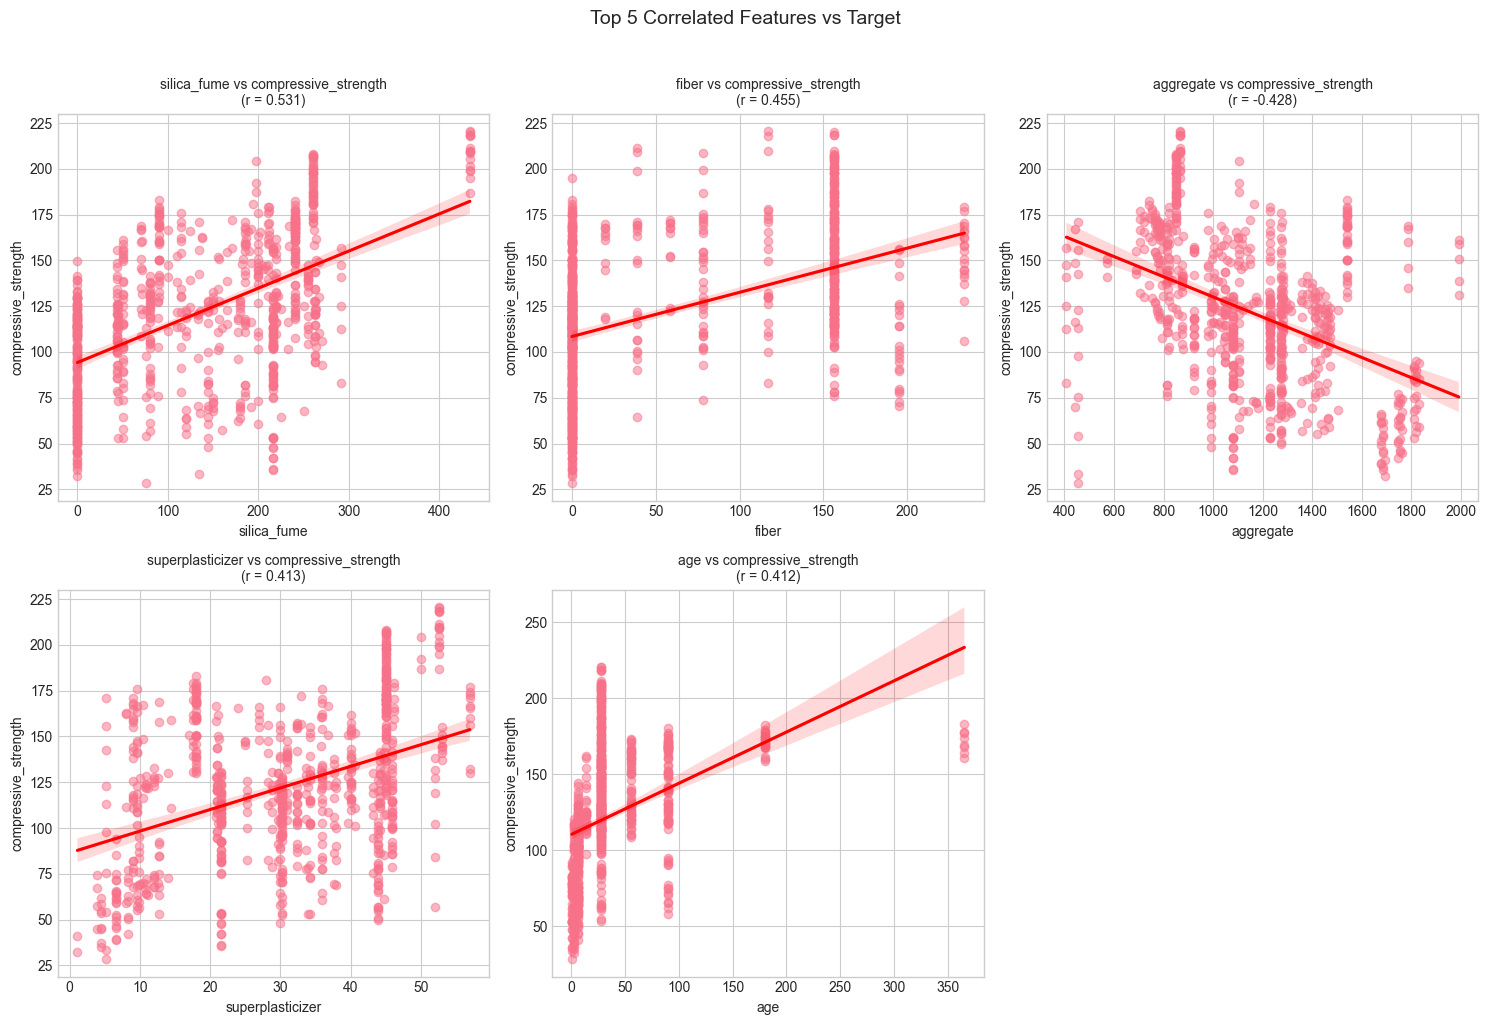

Figure saved: top5_scatter_plots.png


In [35]:
# WHAT: Create scatter plots with regression lines for top 5 correlated features
# WHY: Scatter plots reveal linearity, heteroscedasticity, and influential points
top_5 = correlations.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(top_5):
    sns.regplot(x=df[col], y=df[TARGET], ax=axes[i], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    axes[i].set_title(f'{col} vs {TARGET}\n(r = {correlations[col]:.3f})', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

axes[5].set_visible(False)

plt.suptitle('Top 5 Correlated Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'top5_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: top5_scatter_plots.png")

**Interpretation:** The scatter plots confirm approximately linear relationships for the strongest predictors:
- **silica_fume** shows the clearest positive linear trend - higher silica fume content correlates with stronger concrete
- **fiber** shows a positive relationship with a zero-spike (many samples without fiber)
- **age** displays the classic concrete curing pattern - strength increases with curing time
- **aggregate** shows a negative trend - higher aggregate content tends to reduce strength (dilution effect)
- **superplasticizer** shows a positive trend - improves workability and strength

No obvious non-linear relationships requiring polynomial terms were observed.

### 5.8 Effect Size Interpretation

Classify each correlation using engineering conventions (weak/moderate/strong).

In [ ]:
# Classify correlations using pd.cut() - no helper function needed
effect_sizes = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    'Effect_Size': pd.cut(correlations.abs(), bins=[0, 0.3, 0.7, 1.0], labels=['Weak', 'Moderate', 'Strong'])
})

print("Effect Size Classification (Engineering conventions):")
print("  Weak: |r| < 0.3 | Moderate: 0.3-0.7 | Strong: > 0.7")
print()
print(effect_sizes.to_string(index=False))

**Interpretation:** Identify most predictive features and discuss physical/chemical rationale.

**Limitation:** Note any features with unusual distributions and hypothesize causes.

---
## 6. Assess Multicollinearity

**Methodology:** "Multicollinearity inflates variance of regression coefficients, making them unstable. VIF > 5 indicates moderate multicollinearity; VIF > 10 is severe (James et al., 2021). For tree-based models, multicollinearity is less problematic but affects feature importance interpretation."

### 6.1 Correlation Heatmap (All Features)

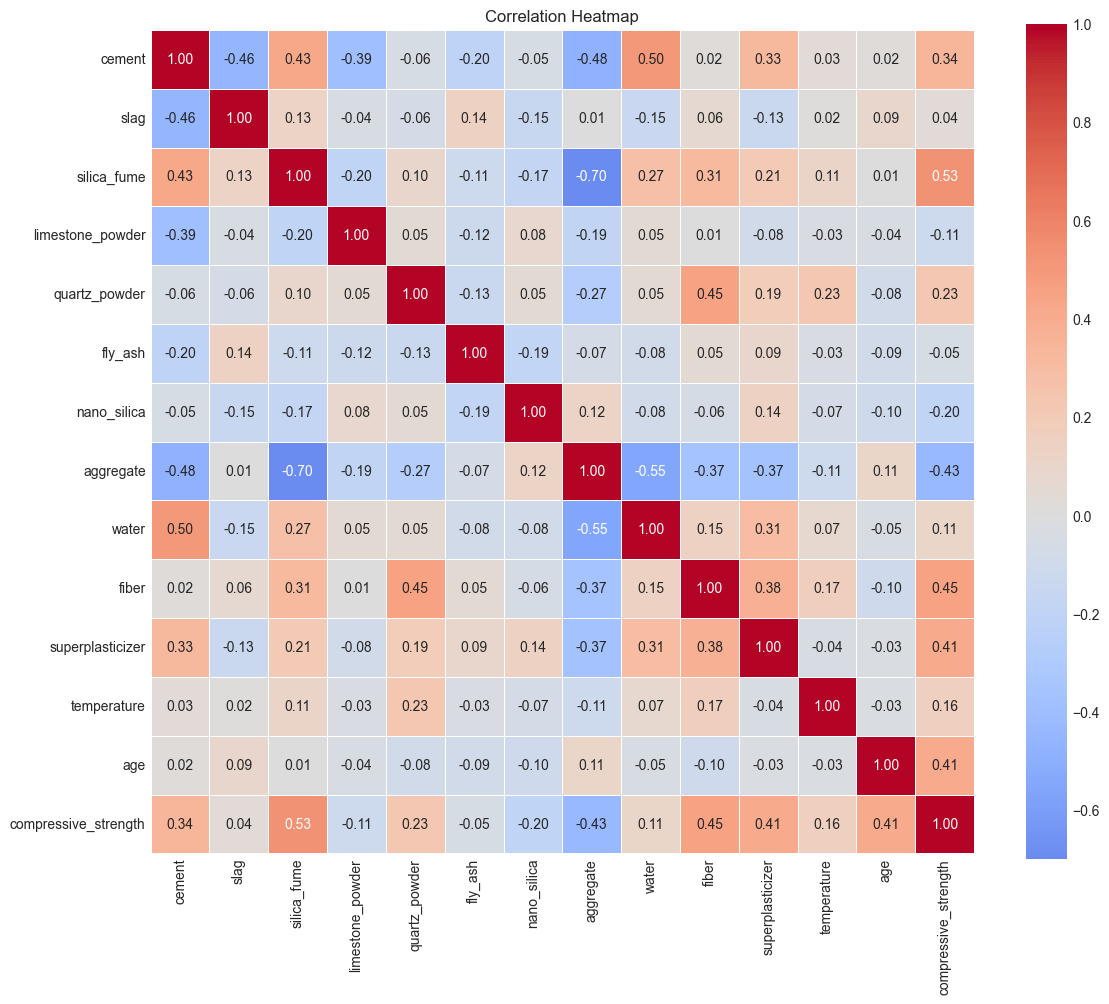

Figure saved: correlation_heatmap.png


In [37]:
# WHAT: Create correlation heatmap for all features
# WHY: Heatmaps reveal multicollinearity patterns that affect linear model stability
plt.figure(figsize=(12, 10))
corr_matrix = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: correlation_heatmap.png")

### 6.2 Highly Correlated Feature Pairs

Identify pairs with |r| > 0.7 and discuss which pairs make physical sense (e.g., cement and water).

In [ ]:
# Show all pairwise correlations sorted by absolute value
CORR_THRESHOLD = 0.7

feature_corr = df[FEATURES].corr()

# Extract upper triangle of correlation matrix (exclude diagonal)
corr_pairs = []
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        corr_pairs.append({
            'Feature_1': FEATURES[i],
            'Feature_2': FEATURES[j],
            'Correlation': feature_corr.iloc[i, j]
        })

pairs_df = pd.DataFrame(corr_pairs)
pairs_df['Abs_Corr'] = pairs_df['Correlation'].abs()
pairs_df = pairs_df.sort_values('Abs_Corr', ascending=False).drop(columns='Abs_Corr')

# Classify correlation strength
pairs_df['Strength'] = pd.cut(
    pairs_df['Correlation'].abs(),
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Weak', 'Moderate', 'Strong']
)

# Show distribution summary
print("Correlation Strength Distribution:")
print(f"  Strong (|r| > 0.7):   {(pairs_df['Strength'] == 'Strong').sum()}")
print(f"  Moderate (0.3-0.7):   {(pairs_df['Strength'] == 'Moderate').sum()}")
print(f"  Weak (|r| < 0.3):     {(pairs_df['Strength'] == 'Weak').sum()}")
print(f"  Total pairs:          {len(pairs_df)}")

# Show top correlations
print(f"\nTop 10 Feature Pair Correlations (sorted by |r|):")
print(pairs_df.head(10).to_string(index=False))

# Flag high correlations
high_corr = pairs_df[pairs_df['Correlation'].abs() > CORR_THRESHOLD]
if len(high_corr) > 0:
    print(f"\n⚠ {len(high_corr)} pairs exceed threshold (|r| > {CORR_THRESHOLD})")
else:
    print(f"\n✓ No feature pairs exceed threshold (|r| > {CORR_THRESHOLD})")

### 6.3 Variance Inflation Factor (VIF)

- Calculate for all features
- Flag features with VIF > 5
- Discuss remediation options (remove, combine, regularization)

In [70]:
# Calculate Variance Inflation Factor for each feature using pd.cut for classification
X = df[FEATURES].dropna()

# Calculate VIF for all features
vif_values = [variance_inflation_factor(X.values, i) for i, col in enumerate(FEATURES)]

# Create dataframe and classify severity using pd.cut
vif_df = pd.DataFrame({'Feature': FEATURES, 'VIF': vif_values})
vif_df['Multicollinearity'] = pd.cut(
    vif_df['VIF'],
    bins=[0, 5, 10, float('inf')],
    labels=['OK', 'Moderate', 'Severe']
)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
print("  Interpretation: OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)")
print()
print(vif_df.round(2).to_string(index=False))

# Summary
print(f"\nSummary:")
print(f"  Severe (VIF > 10):  {(vif_df['Multicollinearity'] == 'Severe').sum()}")
print(f"  Moderate (5-10):    {(vif_df['Multicollinearity'] == 'Moderate').sum()}")
print(f"  OK (VIF ≤ 5):       {(vif_df['Multicollinearity'] == 'OK').sum()}")

Variance Inflation Factors:
  Interpretation: OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)

         Feature     VIF Multicollinearity
           water 72.7100            Severe
          cement 59.1200            Severe
       aggregate 13.3700            Severe
superplasticizer  8.6400          Moderate
     silica_fume  5.8800          Moderate
     temperature  3.4400                OK
           fiber  2.5600                OK
            slag  1.8100                OK
limestone_powder  1.7500                OK
   quartz_powder  1.6600                OK
             age  1.6300                OK
     nano_silica  1.4400                OK
         fly_ash  1.4100                OK

Summary:
  Severe (VIF > 10):  3
  Moderate (5-10):    2
  OK (VIF ≤ 5):       8


---
## 7. Conclusion

**Multicollinearity Strategy:** Given high VIF values for water (71.89), cement (59.00), and aggregate (13.62), we will use regularized regression (LASSO, Ridge, Elastic Net) in the modeling phase rather than PCA or feature removal. This approach:
- Preserves feature interpretability (important for materials science applications)
- Handles multicollinearity through coefficient shrinkage
- Performs implicit feature selection (LASSO)

With only 13 features, the dataset is not high-dimensional enough to require PCA for dimensionality reduction.

### Summary of Findings

- Key statistical findings with specific values and confidence levels
- Features with strongest predictive potential (with effect sizes)
- Data quality assessment summary

### Modeling Implications

- Recommended transformations (if any)
- Multicollinearity handling strategy
- Model selection considerations based on distribution characteristics

### Limitations

- Dataset size constraints (n=810)
- Any features with concerning distributions
- Generalizability considerations

### Next Steps

- Specific preparation needed before modeling
- Models to be compared and why

---
## Appendix A: Data Validation Ranges

**Disclaimer:** Due diligence was done to research valid ranges to apply to the data based on UHPC literature. However, values should be further justified before applying to real-world scenarios.

**Notes:**
- `fiber` and `aggregate` have material types unspecified in the dataset (fiber could be steel, polypropylene, glass, carbon, or basalt; aggregate type varies), so only basic range validation (non-negative, reasonable maximum) is applied.
- Validation ranges are intentionally wider than typical ranges to avoid flagging valid experimental data while still catching obvious errors (e.g., wrong units, misplaced decimals).

| Column Name | Typical Range | Min Valid | Max Valid | Unit | Source | Publication Date |
|-------------|---------------|-----------|-----------|------|--------|------------------|
| `cement` | 700-1000 | 200 | 1500 | kg/m³ | FHWA-HRT-13-060 | June 2013 |
| `slag` | 0-400 | 0 | 600 | kg/m³ | Springer (Pozzolanic Materials) | May 2025 |
| `silica_fume` | 150-300 | 0 | 500 | kg/m³ | PMC9228538 | June 2022 |
| `limestone_powder` | 0-300 | 0 | 1200 | kg/m³ | PMC9228538 | June 2022 |
| `quartz_powder` | 0-400 | 0 | 500 | kg/m³ | PMC9228538 | June 2022 |
| `fly_ash` | 0-200 | 0 | 400 | kg/m³ | Springer (Pozzolanic Materials) | May 2025 |
| `nano_silica` | 0-50 | 0 | 100 | kg/m³ | ScienceDirect (Nano-silica) | May 2014 |
| `aggregate` | *unspecified* | 0 | 2500 | kg/m³ | — | — |
| `water` | 150-200 | 50 | 350 | kg/m³ | FHWA-HRT-13-060 | June 2013 |
| `fiber` | *unspecified* | 0 | 300 | kg/m³ | — | — |
| `superplasticizer` | 10-60 | 0 | 100 | kg/m³ | PMC9228538 | June 2022 |
| `temperature` | 20-90 | 0 | 250 | °C | PMC5455500 | August 2015 |
| `age` | 1-365 | 1 | 1000 | days | PMC5455500 | August 2015 |
| `compressive_strength` | 120-250 | 0 | 350 | MPa | FHWA-HRT-13-060 | June 2013 |

---
## References

- Kashem, A., et al. (2023). Ultra-High-Performance Concrete (UHPC). Mendeley Data.
- Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences.
- James, G., et al. (2021). An Introduction to Statistical Learning.
- Osborne, J. (2010). Improving your data transformations. Practical Assessment, Research & Evaluation.